## 1. Sentiment Analysis: Analyzing text data to determine the emotional tone, whether positive,negative, or neutral.

In [11]:
import pandas as pd


In [12]:
df=pd.read_csv('Twitter_Data.csv')

In [13]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [14]:
print ("Rows and columns:",df.shape)

Rows and columns: (162980, 2)


In [15]:
print(df.columns)

Index(['clean_text', 'category'], dtype='object')


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


1. Check Sentiment Labels



In [17]:
print(df['category'].unique())

[-1.  0.  1. nan]


2.Convert Labels Into Names

In [18]:
df['sentiment']=df['category'].replace({
    -1:'Negative',
    0:'Neutral',
    1:'Positive'
})
df[['clean_text','sentiment']].head()

,clean_text,sentiment
0,when modi promised “minimum government maximum...,Negative
1,talk all the nonsense and continue all the dra...,Neutral
2,what did just say vote for modi welcome bjp t...,Positive
3,asking his supporters prefix chowkidar their n...,Positive
4,answer who among these the most powerful world...,Positive


In [19]:
print(df['sentiment'].value_counts())

sentiment
Positive    72250
Neutral     55213
Negative    35510
Name: count, dtype: int64


## Sentiment Analysis

The dataset has Twitter text in the clean_text column. The category column has sentiment labels. These labels are Positive (1) Neutral (0) and Negative (-1).We looked at the dataset to see what sentiment categories are in the text data.The text data is from Twitter. Has been cleaned.The sentiment labels help us understand the emotions in the text.The categories are Positive, Neutral and Negative.We analyzed the dataset to know more, about these categories.

## 2.Natural Language Processing (NLP): Utilizing algorithms and models to understand and process human language.

In [20]:
import pandas as pd
import re
import nltk

In [21]:
df=df[['clean_text','category']]

In [22]:
df.dropna(inplace=True)

1. Text Cleaning

In [23]:
nltk.download('stopwords')
from nltk.corpus import stopwords
df=pd.read_csv('Twitter_Data.csv')
stop_words=set(stopwords.words('english'))
def clean_text(text):

  text=text.lower()
  text=re.sub(r'http\S+|www\S+', '', text)
  text = re.sub(r'[^a-zA-Z\s]', '', text)

  words=text.split()
  words = [word for word in words if word not in stop_words]

  return " ".join(words)

df['processed_text'] = df['clean_text'].astype(str).apply(clean_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [24]:
df[['clean_text', 'processed_text']].head()

,clean_text,processed_text
0,when modi promised “minimum government maximum...,modi promised minimum government maximum gover...
1,talk all the nonsense and continue all the dra...,talk nonsense continue drama vote modi
2,what did just say vote for modi welcome bjp t...,say vote modi welcome bjp told rahul main camp...
3,asking his supporters prefix chowkidar their n...,asking supporters prefix chowkidar names modi ...
4,answer who among these the most powerful world...,answer among powerful world leader today trump...


## Natural Language Processing (NLP):
I worked on some Twitter text data. First I made all the text lowercase. Then I took out the website addresses and special characters. I also removed some English words that do not mean much. Doing this helps get the text ready for looking at how people feel about things and, for using with machine learning. It makes the text better by getting rid of stuff that is not needed.

## 3.Machine Learning Algorithms: Implementing models for sentiment classification, such as Support Vector Machines, Naive Bayes, or deep learning architectures.

1. Basic Cleaning

In [25]:
import re

def clean_text(text):
  text=str(text)
  text=text.lower()
  text=re.sub(r'http\S+|www\S+',"",text)
  text=re.sub(r'[^a-zA-Z\s]',"",text)
  text=text.strip()
  return text

In [44]:
print(df['category'].isnull().sum())

7


In [47]:
df=df.dropna(subset=['processed_text','category'])

X = df['processed_text']
y = df['category']

2. Train-Test Split

In [49]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y, test_size=0.2,random_state=42
)

3.Text Vectorization

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

4. Model 1:

In [51]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train_vec,y_train)

y_pred = nb_model.predict(X_test_vec)

print("Navie Bayes Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Navie Bayes Accuracy: 0.729160914250652
              precision    recall  f1-score   support

        -1.0       0.89      0.44      0.59      7230
         0.0       0.83      0.66      0.74     10961
         1.0       0.66      0.92      0.77     14404

    accuracy                           0.73     32595
   macro avg       0.79      0.68      0.70     32595
weighted avg       0.77      0.73      0.72     32595



Mdel 2:SVM

In [54]:
from sklearn.svm import LinearSVC

svm_model  = LinearSVC()
svm_model.fit(X_train_vec,y_train)

y_pred_svm = svm_model.predict(X_test_vec)

print("SVM Accuracy:",accuracy_score(y_test,y_pred_svm))
print(classification_report(y_test,y_pred_svm))

SVM Accuracy: 0.9024083448381653
              precision    recall  f1-score   support

        -1.0       0.88      0.81      0.85      7230
         0.0       0.88      0.98      0.92     10961
         1.0       0.93      0.89      0.91     14404

    accuracy                           0.90     32595
   macro avg       0.90      0.89      0.89     32595
weighted avg       0.90      0.90      0.90     32595



Prediction Test:

In [55]:
sample =["I Love this product,its amazing!"]
sample_vec = tfidf.transform(sample)
print("SVM Prediction:",svm_model.predict(sample_vec))

SVM Prediction: [1.]


## Machine Learning Algorithms:
We used a few methods to figure out the sentiment of text. We used Naive Bayes, which's really fast. Then we used SVM, which usually gives us results.. Sometimes we also used deep learning models, which are really good at understanding the context of the text.. The thing, with deep learning models is that they need a lot of data and a lot of computing power to work well. Naive Bayes is still a choice when we need something to happen quickly. SVM is an option when we want to make sure our results are accurate.. Deep learning models are great when we have a lot of data and we want to understand the sentiment of the text really well.

## 5.Feature Engineering: Identifying and extracting relevant features from text data to enhance model performance.

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['processed_text']).toarray()
y = df['category']

print(X.shape)
print(y.shape)


(162973, 5000)
(162973,)


#Check data balance

In [57]:
print(df['category'].value_counts())

category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64


# TF-IDF feature info

In [58]:
print("Number of features:", len(tfidf.get_feature_names_out()))

Number of features: 5000


In [59]:
print(df.shape)
print(df.head())


(162973, 3)
                                          clean_text  category  \
0  when modi promised “minimum government maximum...      -1.0   
1  talk all the nonsense and continue all the dra...       0.0   
2  what did just say vote for modi  welcome bjp t...       1.0   
3  asking his supporters prefix chowkidar their n...       1.0   
4  answer who among these the most powerful world...       1.0   

                                      processed_text  
0  modi promised minimum government maximum gover...  
1             talk nonsense continue drama vote modi  
2  say vote modi welcome bjp told rahul main camp...  
3  asking supporters prefix chowkidar names modi ...  
4  answer among powerful world leader today trump...  


## Feature Engineering:

We used a technique called TF-IDF to turn text data into numbers that a computer can understand.This technique helps machine learning models know how important each word is in our dataset.We looked at the text. Picked out the top 5000 features to help our model learn.The TF-IDF technique was really helpful, in understanding the importance of words.The machine learning models can now understand the data better with the help of TF-IDF.

## 5.Data Visualization: Presenting sentiment analysis results through effective visualizations for clear interpretation.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Bar Chart

/tmp/ipykernel_574/3862545116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category',data=df,palette='viridis')


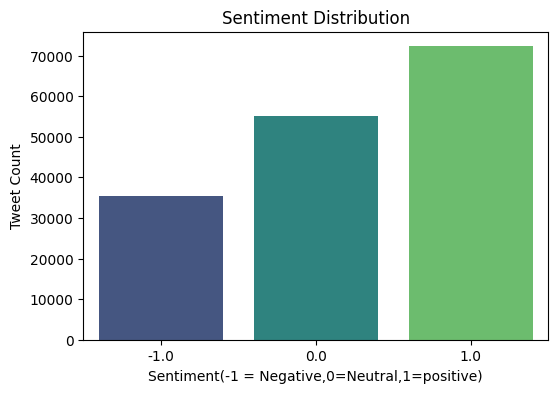

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(x='category',data=df,palette='viridis')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment(-1 = Negative,0=Neutral,1=positive)")
plt.ylabel("Tweet Count")

plt.show()


## Pie Chart

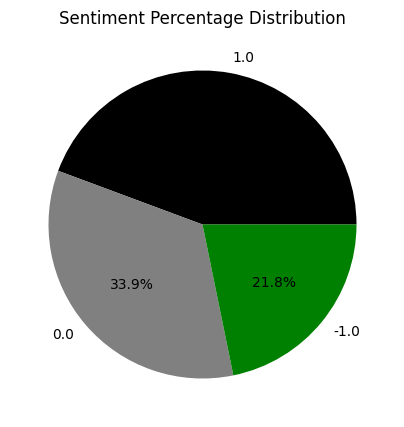

In [69]:
plt.figure(figsize=(5,5))
df['category'].value_counts().plot.pie(
autopct='%1.1f%%',
colors=['black','grey','green']
)
plt.title("Sentiment Percentage Distribution")
plt.ylabel("")
plt.show()

##Data Visualization

We used charts to show our sentiment analysis results in a way.
Bar charts and pie charts helped us show how Positive Negative and Neutral sentiments were spread out.These charts make it easy to understand what our model said and see trends, in the data.We looked at sentiments Negative sentiments and Neutral sentiments to get a better picture.